In [1]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:12<00:00, 12.7MB/s] 


In [29]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision import models
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

PARENT_DIR = 'bean-leaf-lesions-classification/'
print(PARENT_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

bean-leaf-lesions-classification/
cuda


In [30]:
train_df = pd.read_csv('bean-leaf-lesions-classification/train.csv')
val_df = pd.read_csv('bean-leaf-lesions-classification/val.csv')

train_df.head(), val_df.head()

(                            image:FILE  category
 0   train/healthy/healthy_train.98.jpg         0
 1  train/healthy/healthy_train.148.jpg         0
 2  train/healthy/healthy_train.306.jpg         0
 3  train/healthy/healthy_train.305.jpg         0
 4   train/healthy/healthy_train.40.jpg         0,
                        image:FILE  category
 0  val/healthy/healthy_val.25.jpg         0
 1  val/healthy/healthy_val.32.jpg         0
 2   val/healthy/healthy_val.3.jpg         0
 3  val/healthy/healthy_val.16.jpg         0
 4  val/healthy/healthy_val.10.jpg         0)

In [31]:
train_df['category'].unique()

array([0, 1, 2])

In [32]:
print(train_df.shape, val_df.shape)

(1034, 2) (133, 2)


In [33]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [62]:
class CustomImageDataSet(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.labels = torch.tensor(df['category']).to(device)

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(PARENT_DIR + img_path)
        if self.transform:
            image = (self.transform(image) / 255.0).to(device)
        
        return image, label


In [63]:
train_dataset = CustomImageDataSet(train_df, transform=transform)
val_dataset = CustomImageDataSet(val_df, transform=transform)

train_dataset.__len__()

1034

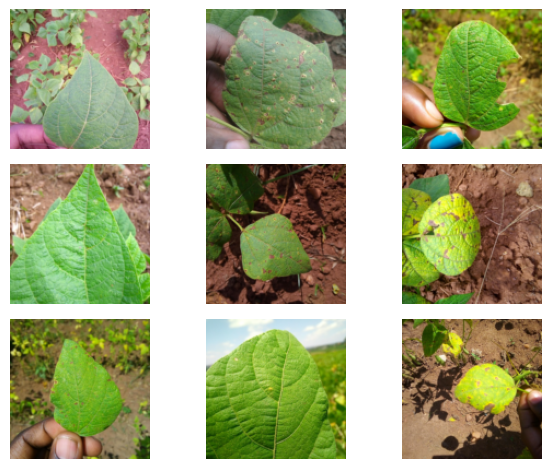

In [64]:
n_rows, n_cols = 3, 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
        axarr[row, col].imshow((image*255.0).squeeze().permute(1, 2, 0))
        axarr[row, col].axis('off')

plt.tight_layout()
plt.show()


In [65]:
LR = 1e-3
BATCH_SIZE = 4
EPOCHS = 15

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
googlenet_model = models.googlenet(weights='DEFAULT')

In [67]:
for param in googlenet_model.parameters():
    param.requires_grad = True

googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [68]:
num_classes = len(train_df['category'].unique())
num_classes

3

In [69]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [70]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [71]:
loss_func = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0 

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        
        outputs = googlenet_model(inputs)
        
        train_loss = loss_func(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(outputs, axis = 1) == labels).sum()
        total_acc_train += train_acc.item()

        optimizer.step()

    total_loss_train_plot.append(round(total_loss_train / 1000, 4))
    total_acc_train_plot.append(round(total_acc_train / train_dataset.__len__() * 100, 4))

    print(f"Epoch: {epoch + 1}, Loss: {total_loss_train_plot[-1]}, Accuracy: {total_acc_train_plot[-1]}")

Epoch: 1, Loss: 0.2608, Accuracy: 49.5164
Epoch: 2, Loss: 0.2402, Accuracy: 56.7698
Epoch: 3, Loss: 0.2037, Accuracy: 66.9246
Epoch: 4, Loss: 0.2022, Accuracy: 67.8917
Epoch: 5, Loss: 0.1834, Accuracy: 70.8897
Epoch: 6, Loss: 0.1891, Accuracy: 69.4391
Epoch: 7, Loss: 0.1758, Accuracy: 70.5996
Epoch: 8, Loss: 0.157, Accuracy: 76.6925
Epoch: 9, Loss: 0.1359, Accuracy: 78.7234
Epoch: 10, Loss: 0.146, Accuracy: 77.7563
Epoch: 11, Loss: 0.1418, Accuracy: 78.6267
Epoch: 12, Loss: 0.1227, Accuracy: 81.528
Epoch: 13, Loss: 0.1145, Accuracy: 83.2689
Epoch: 14, Loss: 0.1263, Accuracy: 82.3985
Epoch: 15, Loss: 0.112, Accuracy: 83.3656


In [72]:
with torch.no_grad():
    total_acc_test = 0
    total_loss_test = 0

    for idx, (inputs, labels) in enumerate(val_loader):
        predictions = googlenet_model(inputs)

        acc = (torch.argmax(predictions, axis=1) == labels).sum()
        total_acc_test += acc.item()

print(f"Accuracy: {total_acc_test / val_dataset.__len__() * 100}")

Accuracy: 81.203007518797


### Transfer Learning

In [75]:
googlenet_model1 = models.googlenet(weights='DEFAULT')

for param in googlenet_model1.parameters():
    param.requires_grad = False

googlenet_model1.fc = torch.nn.Linear(googlenet_model1.fc.in_features, num_classes)
googlenet_model1.requires_grad = True
googlenet_model1.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [76]:
loss_func = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0 

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        
        outputs = googlenet_model1(inputs)
        
        train_loss = loss_func(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(outputs, axis = 1) == labels).sum()
        total_acc_train += train_acc.item()

        optimizer.step()

    total_loss_train_plot.append(round(total_loss_train / 1000, 4))
    total_acc_train_plot.append(round(total_acc_train / train_dataset.__len__() * 100, 4))

    print(f"Epoch: {epoch + 1}, Loss: {total_loss_train_plot[-1]}, Accuracy: {total_acc_train_plot[-1]}")

Epoch: 1, Loss: 0.2996, Accuracy: 34.1393
Epoch: 2, Loss: 0.3014, Accuracy: 33.559
Epoch: 3, Loss: 0.3014, Accuracy: 34.4294
Epoch: 4, Loss: 0.3015, Accuracy: 34.0426
Epoch: 5, Loss: 0.3022, Accuracy: 34.0426
Epoch: 6, Loss: 0.3012, Accuracy: 34.1393
Epoch: 7, Loss: 0.2999, Accuracy: 34.3327
Epoch: 8, Loss: 0.3002, Accuracy: 34.7195
Epoch: 9, Loss: 0.3012, Accuracy: 33.8491
Epoch: 10, Loss: 0.3014, Accuracy: 35.2031
Epoch: 11, Loss: 0.2994, Accuracy: 34.4294
Epoch: 12, Loss: 0.3007, Accuracy: 34.8162
Epoch: 13, Loss: 0.2996, Accuracy: 33.1721
Epoch: 14, Loss: 0.3027, Accuracy: 34.5261
Epoch: 15, Loss: 0.301, Accuracy: 35.1064


In [77]:
with torch.no_grad():
    total_acc_test = 0
    total_loss_test = 0

    for idx, (inputs, labels) in enumerate(val_loader):
        predictions = googlenet_model1(inputs)

        acc = (torch.argmax(predictions, axis=1) == labels).sum()
        total_acc_test += acc.item()

print(f"Accuracy: {total_acc_test / val_dataset.__len__() * 100}")

Accuracy: 34.58646616541353
